In [48]:
# 📦 Retail Sales Forecasting Pipeline
# Author: Rimple Patel (Data Scientist)
# Purpose: Analyze sales trends, forecast future demand, and evaluate accuracy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")


In [49]:
# -------------------------------
# 1️⃣ Load the dataset
# -------------------------------
df = pd.read_csv("Walmart Data Analysis and Forcasting.csv")

In [50]:
# Detect columns
date_col = [c for c in df.columns if 'date' in c.lower()][0]
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]


In [51]:
# Convert date column
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


In [52]:
# Drop missing
df = df.dropna(subset=[date_col, sales_col])

In [53]:
# -------------------------------
# 2️⃣ Aggregate to monthly totals
# -------------------------------
df['year_month'] = df[date_col].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby('year_month')[sales_col].sum().reset_index()
monthly.columns = ['date', 'sales']
monthly = monthly.sort_values('date')

In [54]:
# -------------------------------
# 3️⃣ Create lag & rolling features
# -------------------------------
def create_lags(df, nlags=12):
    data = df.copy()
    for lag in range(1, nlags+1):
        data[f'lag_{lag}'] = data['sales'].shift(lag)
    data['rolling_3'] = data['sales'].rolling(3).mean().shift(1)
    data['rolling_6'] = data['sales'].rolling(6).mean().shift(1)
    data = data.dropna()
    return data

monthly_feat = create_lags(monthly, nlags=12)


In [66]:
# -------------------------------
# 4️⃣ Train-test split
# -------------------------------
n_periods = 12
train = monthly_feat.iloc[:-n_periods]
test = monthly_feat.iloc[-n_periods:]

# Drop non-numeric columns before training
X_train = train.drop(columns=['sales', 'date'], errors='ignore')
y_train = train['sales']
X_test = test.drop(columns=['sales', 'date'], errors='ignore')
y_test = test['sales']

print(f"✅ Training on {len(X_train)} months, testing on {len(X_test)} months.")


✅ Training on 12 months, testing on 12 months.


In [67]:
# -------------------------------
# 5️⃣ Train Random Forest model
# -------------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [70]:
# Evaluate model
y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = mean_squared_error(y_test, y_pred_test) ** 0.5  # compatible version

print(f"📊 Test MAE: {mae:,.2f}")
print(f"📉 Test RMSE: {rmse:,.2f}")

📊 Test MAE: 37,249,692.35
📉 Test RMSE: 38,342,791.31


In [71]:
# -------------------------------
# 7️⃣ Future Forecast (Next 12 months)
# -------------------------------
nlags = 12
cur_series = monthly.copy().set_index('date')['sales']
future_preds = []

for step in range(12):
    last_vals = cur_series.iloc[-nlags:].values
    feat = {f'lag_{i+1}': last_vals[-(i+1)] for i in range(nlags)}
    feat['rolling_3'] = cur_series.tail(3).mean()
    feat['rolling_6'] = cur_series.tail(6).mean()

    feat_df = pd.DataFrame([feat])
    feat_df = feat_df.reindex(columns=X_train.columns, fill_value=0)
    pred = model.predict(feat_df)[0]

    next_date = cur_series.index.max() + pd.DateOffset(months=1)
    cur_series.loc[next_date] = pred
    future_preds.append({'date': next_date, 'predicted_sales': pred})

future_df = pd.DataFrame(future_preds).set_index('date')


In [72]:
# -------------------------------
# 8️⃣ Baseline comparison
# -------------------------------
naive_pred = np.repeat(monthly['sales'].iloc[-1], len(y_test))
rolling_mean_pred = monthly['sales'].rolling(3).mean().shift(1).dropna().iloc[-len(y_test):].values
if len(rolling_mean_pred) != len(y_test):
    rolling_mean_pred = np.repeat(monthly['sales'].mean(), len(y_test))

naive_mae = mean_absolute_error(y_test, naive_pred)
rolling_mae = mean_absolute_error(y_test, rolling_mean_pred)


In [73]:
# -------------------------------
# 9️⃣ Results summary
# -------------------------------
summary_df = pd.DataFrame({
    "Metric": ["MAE (Model)", "RMSE (Model)", "MAE (Naive)", "MAE (Rolling-3)"],
    "Value": [mae, rmse, naive_mae, rolling_mae]
})
print("\n📈 Model Evaluation Summary:")
print(summary_df)



📈 Model Evaluation Summary:
            Metric         Value
0      MAE (Model)  3.724969e+07
1     RMSE (Model)  3.834279e+07
2      MAE (Naive)  1.795855e+07
3  MAE (Rolling-3)  3.421061e+07


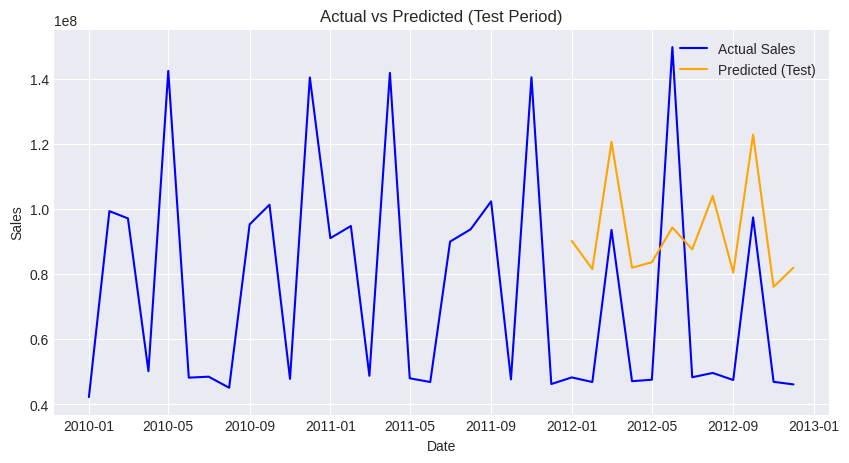

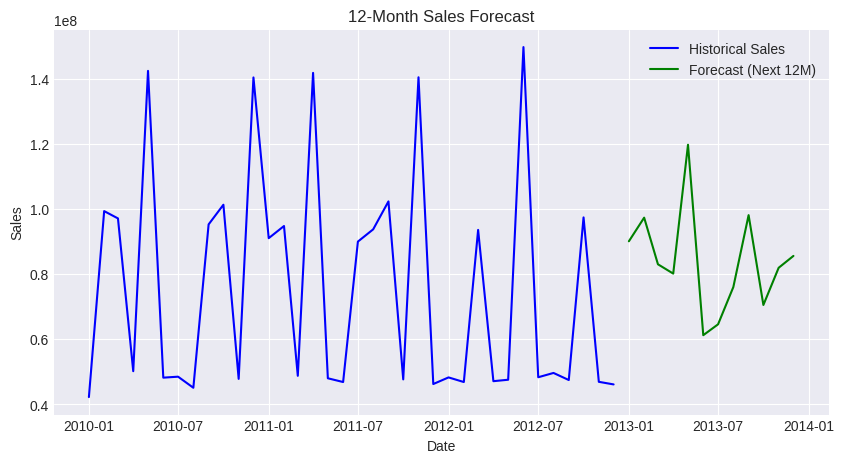

In [74]:
# -------------------------------
# 🔟 Visualization
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(monthly['date'], monthly['sales'], label='Actual Sales', color='blue')
plt.plot(test['date'], y_pred_test, label='Predicted (Test)', color='orange')
plt.title("Actual vs Predicted (Test Period)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(monthly['date'], monthly['sales'], label='Historical Sales', color='blue')
plt.plot(future_df.index, future_df['predicted_sales'], label='Forecast (Next 12M)', color='green')
plt.title("12-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [75]:
# -------------------------------
# 1️⃣1️⃣ Save forecast
# -------------------------------
future_df.to_csv("monthly_sales_forecast.csv")
print("\n✅ Forecast saved as 'monthly_sales_forecast.csv'")


✅ Forecast saved as 'monthly_sales_forecast.csv'
